LEVEL 2 - TASK 1: LOGISTIC REGRESSION
📁 Dataset path: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\datasets\1) iris.csv

STEP 2: LOAD AND PREPARE DATA
✅ Loaded from: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\datasets\1) iris.csv

📌 DATASET SHAPE: 150 rows × 6 columns

📌 BINARY TARGET DISTRIBUTION:
   Setosa (1): 50 samples
   Non-Setosa (0): 100 samples

📌 Training set: 120 samples
📌 Testing set: 30 samples

STEP 3: TRAIN LOGISTIC REGRESSION
✅ Model trained successfully!

STEP 4: INTERPRET COEFFICIENTS

📌 MODEL COEFFICIENTS:
        Feature  Coefficient  Odds_Ratio
1   sepal_width     1.323324    3.755887
0  sepal_length    -0.934347    0.392842
3   petal_width    -1.532189    0.216062
2  petal_length    -1.639085    0.194158

📌 INTERCEPT: -2.3289

STEP 5: MAKE PREDICTIONS

STEP 6: EVALUATE MODEL

📌 CLASSIFICATION METRICS:
   • Accuracy:  1.0000
   • Precision: 1.0000
   • Recall:    1.0000
   • F1-Score:  1.0000

📌 CONFUSION MATRIX:
[[20  0]


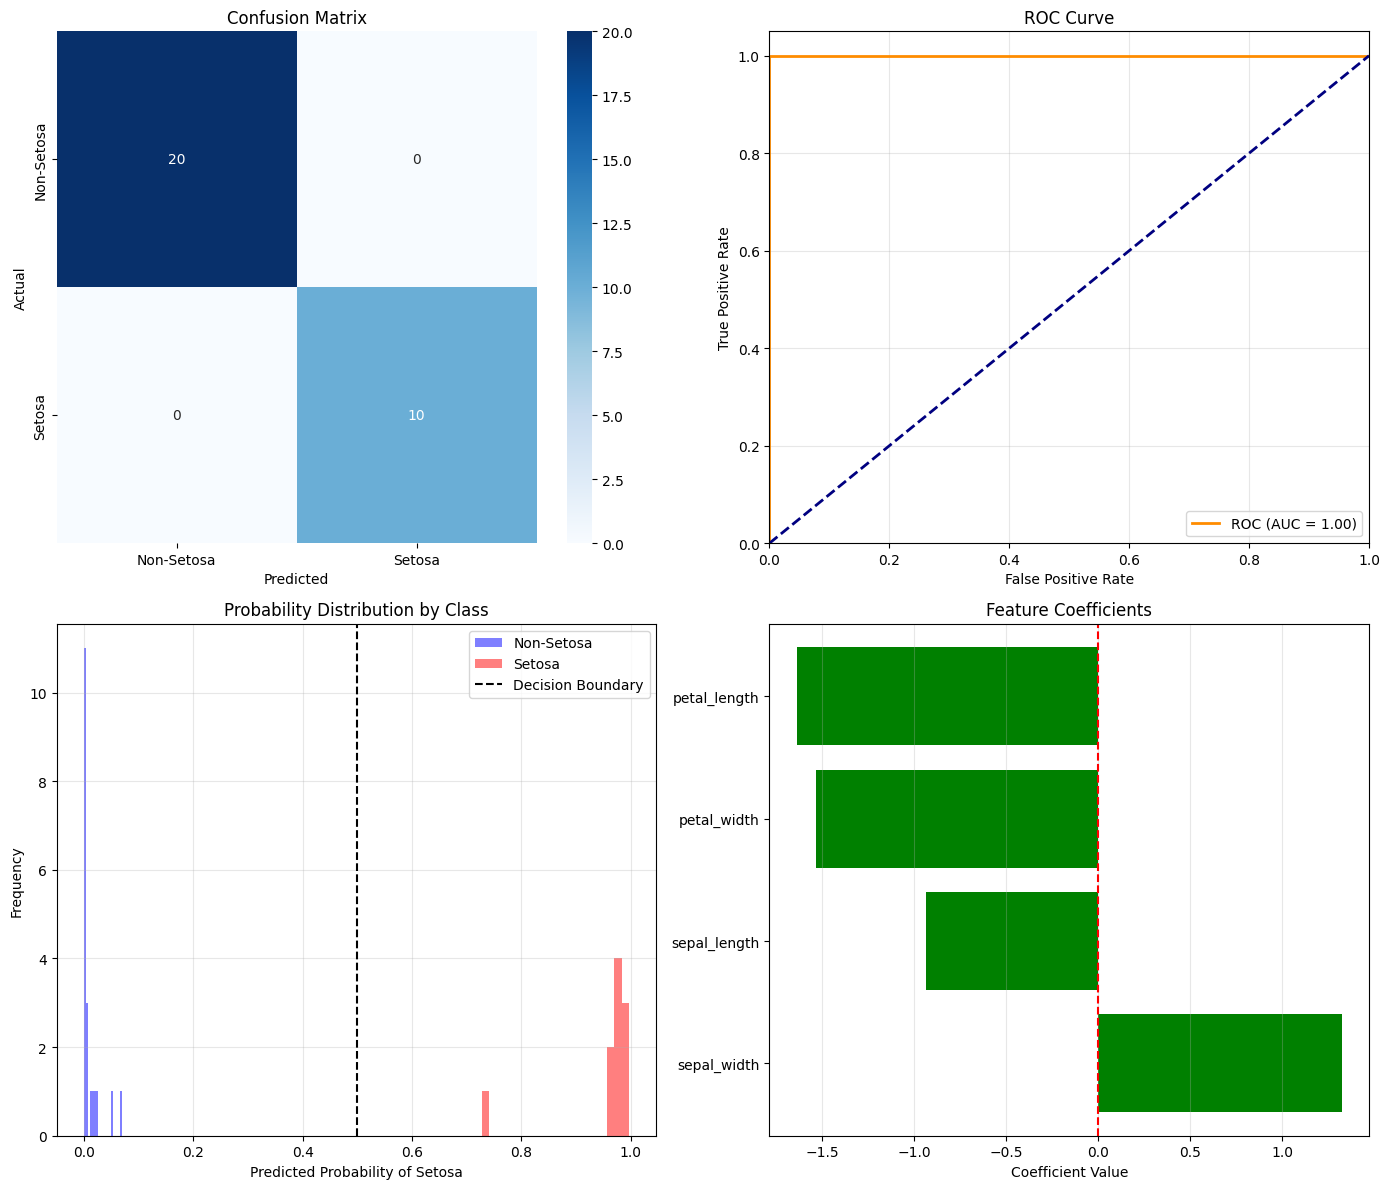

✅ Saved: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\images\logistic_regression_results.png

STEP 9: SAVE RESULTS
✅ Saved: c:\Users\HP\Desktop\PDF\WORKSPACE\Projects\ML_Internship_Project\outputs\logistic_regression_results.csv

STEP 10: SUMMARY

╔════════════════════════════════════════════════════════════════════════════╗
║                    LEVEL 2 - TASK 1 COMPLETED                             ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  ✅ Logistic Regression for Binary Classification                         ║
║                                                                            ║
║  PERFORMANCE:                                                             ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • Accuracy:  1.0000                                              ║
║  • Precision: 1.0000             

In [1]:
"""
================================================================================
LEVEL 2 - TASK 1: LOGISTIC REGRESSION FOR BINARY CLASSIFICATION
================================================================================
Objective: Predict whether an iris flower is Setosa or not
Dataset: Iris Dataset
================================================================================
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

print("="*80)
print("LEVEL 2 - TASK 1: LOGISTIC REGRESSION")
print("="*80)

# ============================================================================
# STEP 1: SETUP PATHS
# ============================================================================

current_dir = os.path.dirname(os.path.abspath('__file__')) if '__file__' in dir() else os.getcwd()
main_dir = os.path.dirname(current_dir)
dataset_path = os.path.join(main_dir, 'datasets', '1) iris.csv')
output_dir = os.path.join(main_dir, 'outputs')
image_dir = os.path.join(main_dir, 'images')

os.makedirs(output_dir, exist_ok=True)
os.makedirs(image_dir, exist_ok=True)

print(f"📁 Dataset path: {dataset_path}")

# ============================================================================
# STEP 2: LOAD AND PREPARE DATA
# ============================================================================

print("\n" + "="*80)
print("STEP 2: LOAD AND PREPARE DATA")
print("="*80)

# Load dataset
if os.path.exists(dataset_path):
    iris_df = pd.read_csv(dataset_path)
    print(f"✅ Loaded from: {dataset_path}")
else:
    alt_paths = ['../datasets/1) iris.csv', './datasets/1) iris.csv', '1) iris.csv']
    for path in alt_paths:
        if os.path.exists(path):
            iris_df = pd.read_csv(path)
            print(f"✅ Loaded from: {path}")
            break

# Create binary target: 1 for Setosa, 0 for others
iris_df['is_setosa'] = (iris_df['species'] == 'setosa').astype(int)

print(f"\n📌 DATASET SHAPE: {iris_df.shape[0]} rows × {iris_df.shape[1]} columns")
print(f"\n📌 BINARY TARGET DISTRIBUTION:")
print(f"   Setosa (1): {sum(iris_df['is_setosa']==1)} samples")
print(f"   Non-Setosa (0): {sum(iris_df['is_setosa']==0)} samples")

# Features
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
X = iris_df[features]
y = iris_df['is_setosa']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📌 Training set: {X_train.shape[0]} samples")
print(f"📌 Testing set: {X_test.shape[0]} samples")

# ============================================================================
# STEP 3: TRAIN LOGISTIC REGRESSION
# ============================================================================

print("\n" + "="*80)
print("STEP 3: TRAIN LOGISTIC REGRESSION")
print("="*80)

log_reg = LogisticRegression(random_state=42)
log_reg.fit(X_train, y_train)

print("✅ Model trained successfully!")

# ============================================================================
# STEP 4: INTERPRET COEFFICIENTS
# ============================================================================

print("\n" + "="*80)
print("STEP 4: INTERPRET COEFFICIENTS")
print("="*80)

coeff_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': log_reg.coef_[0],
    'Odds_Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Coefficient', ascending=False)

print("\n📌 MODEL COEFFICIENTS:")
print(coeff_df)
print(f"\n📌 INTERCEPT: {log_reg.intercept_[0]:.4f}")

# ============================================================================
# STEP 5: MAKE PREDICTIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 5: MAKE PREDICTIONS")
print("="*80)

y_pred = log_reg.predict(X_test)
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# ============================================================================
# STEP 6: EVALUATE MODEL
# ============================================================================

print("\n" + "="*80)
print("STEP 6: EVALUATE MODEL")
print("="*80)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"\n📌 CLASSIFICATION METRICS:")
print(f"   • Accuracy:  {accuracy:.4f}")
print(f"   • Precision: {precision:.4f}")
print(f"   • Recall:    {recall:.4f}")
print(f"   • F1-Score:  {f1:.4f}")

print("\n📌 CONFUSION MATRIX:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\n📌 CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Non-Setosa', 'Setosa']))

# ============================================================================
# STEP 7: ROC CURVE
# ============================================================================

print("\n" + "="*80)
print("STEP 7: ROC CURVE ANALYSIS")
print("="*80)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(f"📌 AUC Score: {roc_auc:.4f}")

# ============================================================================
# STEP 8: VISUALIZE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 8: VISUALIZE RESULTS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0],
            xticklabels=['Non-Setosa', 'Setosa'],
            yticklabels=['Non-Setosa', 'Setosa'])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xlabel('Predicted')

# 2. ROC Curve
axes[0,1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
axes[0,1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
axes[0,1].set_xlim([0.0, 1.0])
axes[0,1].set_ylim([0.0, 1.05])
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend(loc="lower right")
axes[0,1].grid(True, alpha=0.3)

# 3. Probability Distribution
axes[1,0].hist(y_pred_proba[y_test==0], bins=20, alpha=0.5, label='Non-Setosa', color='blue')
axes[1,0].hist(y_pred_proba[y_test==1], bins=20, alpha=0.5, label='Setosa', color='red')
axes[1,0].axvline(x=0.5, color='black', linestyle='--', label='Decision Boundary')
axes[1,0].set_xlabel('Predicted Probability of Setosa')
axes[1,0].set_ylabel('Frequency')
axes[1,0].set_title('Probability Distribution by Class')
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

# 4. Coefficients Bar Chart
axes[1,1].barh(coeff_df['Feature'], coeff_df['Coefficient'], color='green')
axes[1,1].axvline(x=0, color='red', linestyle='--')
axes[1,1].set_xlabel('Coefficient Value')
axes[1,1].set_title('Feature Coefficients')
axes[1,1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(image_dir, 'logistic_regression_results.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Saved: {os.path.join(image_dir, 'logistic_regression_results.png')}")

# ============================================================================
# STEP 9: SAVE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 9: SAVE RESULTS")
print("="*80)

results_df = pd.DataFrame({
    'Actual': ['Setosa' if x == 1 else 'Other' for x in y_test],
    'Predicted': ['Setosa' if x == 1 else 'Other' for x in y_pred],
    'Probability': y_pred_proba,
    'Correct': y_test == y_pred
})
results_df.to_csv(os.path.join(output_dir, 'logistic_regression_results.csv'), index=False)
print(f"✅ Saved: {os.path.join(output_dir, 'logistic_regression_results.csv')}")

# ============================================================================
# STEP 10: SUMMARY
# ============================================================================

print("\n" + "="*80)
print("STEP 10: SUMMARY")
print("="*80)

print(f"""
╔════════════════════════════════════════════════════════════════════════════╗
║                    LEVEL 2 - TASK 1 COMPLETED                             ║
╠════════════════════════════════════════════════════════════════════════════╣
║                                                                            ║
║  ✅ Logistic Regression for Binary Classification                         ║
║                                                                            ║
║  PERFORMANCE:                                                             ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • Accuracy:  {accuracy:.4f}                                              ║
║  • Precision: {precision:.4f}                                             ║
║  • Recall:    {recall:.4f}                                                ║
║  • F1-Score:  {f1:.4f}                                                    ║
║  • AUC:       {roc_auc:.4f}                                               ║
║                                                                            ║
║  OUTPUT FILES:                                                            ║
║  ──────────────────────────────────────────────────────────────────────── ║
║  • outputs/logistic_regression_results.csv                                ║
║  • images/logistic_regression_results.png                                 ║
║                                                                            ║
╚════════════════════════════════════════════════════════════════════════════╝
""")

print("\n🎉 LOGISTIC REGRESSION COMPLETED SUCCESSFULLY!")